# TerraWatch — Aftershock Sequence Transformer
## Predicting aftershock probability from USGS earthquake catalog

**Run on Colab or Kaggle (GPU recommended but not required)**

What we're doing:
- Current standard (ETAS) is a 1980s statistical model
- We train a transformer on historical earthquake sequences from USGS
- Input: mainshock magnitude, depth, location, time
- Output: probability distribution of M>4 aftershocks over next 24h
- This is the 'aftershock forecast' panel in the TerraWatch dashboard

In [45]:
!pip install -q requests pandas numpy torch matplotlib scikit-learn tqdm

import requests
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import json, math, time
from pathlib import Path
from tqdm import tqdm

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')
BASE_DIR = Path('/kaggle/working/aftershock') if Path('/kaggle').exists() else Path('./aftershock')
BASE_DIR.mkdir(exist_ok=True)

Device: cuda


In [46]:
# ── FETCH USGS EARTHQUAKE CATALOG ────────────────────────────────────────────
# Tries 3 methods in order:
#   1. Cached CSV on disk (fastest — skips everything if already fetched)
#   2. Kaggle dataset (kaggle.com/datasets/usgs/earthquake-database)
#   3. Direct USGS API (may be blocked in some cloud environments)

import os

# ── METHOD 1: Check for Kaggle dataset attachment ─────────────────────────────
# Dataset: https://www.kaggle.com/datasets/thedevastator/uncovering-geophysical-insights-analyzing-usgs-e
# On Kaggle: attach via the Data tab — it will appear at the path below.
KAGGLE_DATASET_DIR = Path('/kaggle/input/datasets/thedevastator/uncovering-geophysical-insights-analyzing-usgs-e')

def find_kaggle_csv(dataset_dir):
    """Find the main earthquake CSV inside the dataset directory."""
    if not dataset_dir.exists():
        return None
    csvs = list(dataset_dir.glob('*.csv'))
    if not csvs:
        return None
    # Prefer the largest CSV (most data)
    return max(csvs, key=lambda p: p.stat().st_size)

def load_from_kaggle_dataset(path):
    """
    Load the thedevastator USGS dataset.
    This is a standard USGS ComCat CSV export with columns:
      time, latitude, longitude, depth, mag, magType, ...
    The 'time' column is an ISO8601 string like '2023-01-01T00:00:00.000Z'
    """
    raw = pd.read_csv(path, low_memory=False)
    raw.columns = [c.strip().lower() for c in raw.columns]
    print(f'  Columns found: {list(raw.columns[:10])}...')

    # ── Handle USGS ComCat format (time, latitude, longitude, depth, mag) ──
    if 'time' in raw.columns and 'latitude' in raw.columns:
        raw = raw.dropna(subset=['latitude', 'longitude', 'depth', 'mag'])
        raw['datetime'] = pd.to_datetime(raw['time'], utc=True, errors='coerce')
        raw = raw.dropna(subset=['datetime'])
        df = pd.DataFrame({
            'time':     raw['datetime'].astype(np.int64) // 10**9,
            'mag':      raw['mag'].astype(float),
            'lon':      raw['longitude'].astype(float),
            'lat':      raw['latitude'].astype(float),
            'depth_km': raw['depth'].astype(float),
            'event_id': raw.get('id', raw.index.astype(str)),
            'datetime': raw['datetime'].values,
        })

    # ── Handle older Date/Time/Latitude/Longitude/Magnitude format ──
    elif 'date' in raw.columns and 'magnitude' in raw.columns:
        raw = raw.dropna(subset=['latitude', 'longitude', 'depth', 'magnitude'])
        raw['datetime'] = pd.to_datetime(
            raw['date'].astype(str) + ' ' + raw.get('time', pd.Series(['00:00:00'] * len(raw))).astype(str),
            errors='coerce', utc=True)
        raw = raw.dropna(subset=['datetime'])
        df = pd.DataFrame({
            'time':     raw['datetime'].astype(np.int64) // 10**9,
            'mag':      raw['magnitude'].astype(float),
            'lon':      raw['longitude'].astype(float),
            'lat':      raw['latitude'].astype(float),
            'depth_km': raw['depth'].astype(float),
            'event_id': raw.index.astype(str),
            'datetime': raw['datetime'].values,
        })

    else:
        raise ValueError(f'Unrecognised CSV format. Columns: {list(raw.columns)}')

    df = df[df['mag'] >= 2.5].sort_values('time').reset_index(drop=True)
    return df


# ── METHOD 2: USGS ComCat API (chunked to stay under 20k/request limit) ──────
# def fetch_usgs_catalog(min_mag=2.5, start_year=2000, end_year=2023, chunk_years=2):
#     all_events = []
#     for year in range(start_year, end_year, chunk_years):
#         start = f'{year}-01-01'
#         end   = f'{min(year + chunk_years, end_year)}-01-01'
#         url = 'https://earthquake.usgs.gov/fdsnws/event/1/query'
#         params = {
#             'format': 'geojson', 'starttime': start, 'endtime': end,
#             'minmagnitude': min_mag, 'orderby': 'time-asc',
#         }
#         try:
#             resp = requests.get(url, params=params, timeout=60)
#             resp.raise_for_status()
#             events = resp.json().get('features', [])
#             all_events.extend(events)
#             print(f'{year}-{year+chunk_years}: {len(events)} events (total: {len(all_events)})')
#             time.sleep(1)
#         except Exception as e:
#             print(f'  API failed for {year}: {e}')
#     return all_events

def fetch_usgs_catalog(min_mag=2.5, start_year=2000, end_year=2024):
    all_events = []
    print(f"Fetching USGS catalog from {start_year} to {end_year} by month...")
    
    for year in range(start_year, end_year):
        for month in range(1, 13):
            # Format start and end dates for the month
            start_date = f'{year}-{month:02d}-01'
            if month == 12:
                end_date = f'{year+1}-01-01'
            else:
                end_date = f'{year}-{month+1:02d}-01'
                
            url = 'https://earthquake.usgs.gov/fdsnws/event/1/query'
            params = {
                'format': 'geojson', 
                'starttime': start_date, 
                'endtime': end_date,
                'minmagnitude': min_mag, 
                'orderby': 'time-asc',
            }
            try:
                resp = requests.get(url, params=params, timeout=60)
                resp.raise_for_status()
                events = resp.json().get('features', [])
                all_events.extend(events)
                print(f'  {start_date} to {end_date}: {len(events):,} events (Total: {len(all_events):,})')
                time.sleep(0.5) # Be gentle to the USGS servers
            except Exception as e:
                print(f'  API failed for {start_date}: {e}')
                
    return all_events

def parse_catalog(events):
    rows = []
    for ev in events:
        props = ev['properties']
        geom  = ev['geometry']
        coords = geom['coordinates'] if geom else [None, None, None]
        if None in coords or props.get('mag') is None:
            continue
        rows.append({
            'time':     props['time'] / 1000,
            'mag':      float(props['mag']),
            'lon':      float(coords[0]),
            'lat':      float(coords[1]),
            'depth_km': float(coords[2]) if coords[2] else 10.0,
            'event_id': ev['id'],
        })
    df = pd.DataFrame(rows).sort_values('time').reset_index(drop=True)
    df['datetime'] = pd.to_datetime(df['time'], unit='s')
    return df


# ── LOAD WITH FALLBACK CHAIN ──────────────────────────────────────────────────
catalog_path = BASE_DIR / 'usgs_catalog.csv'

# if catalog_path.exists():
#     print('✅ Loading cached catalog from disk...')
#     df = pd.read_csv(catalog_path)
#     df['datetime'] = pd.to_datetime(df['datetime'])

# elif (kaggle_csv := find_kaggle_csv(KAGGLE_DATASET_DIR)) is not None:
#     print(f'✅ Loading from Kaggle dataset: {kaggle_csv.name}')
#     df = load_from_kaggle_dataset(kaggle_csv)
#     df.to_csv(catalog_path, index=False)
#     print(f'   Cached {len(df):,} events to {catalog_path}')

# else:
print('⏳ Fetching from USGS API (takes a few minutes)...')
print('   If this fails, on Kaggle add the dataset: usgs/earthquake-database')
events = fetch_usgs_catalog(min_mag=2.5, start_year=2000, end_year=2023)
if not events:
    raise RuntimeError(
        'USGS API returned no data — your environment likely blocks external requests.\n'
        'FIX: On Kaggle, open the Data tab on the right → Add Dataset → search "usgs earthquake-database"\n'
        '     Then re-run this cell. The notebook will detect and load it automatically.'
    )
df = parse_catalog(events)
df.to_csv(catalog_path, index=False)

print(f'\nCatalog: {len(df):,} earthquakes')
print(f'Date range: {df["datetime"].min()} → {df["datetime"].max()}')
print(f'Magnitude: {df["mag"].min():.1f} – {df["mag"].max():.1f}')
df.head()

⏳ Fetching from USGS API (takes a few minutes)...
   If this fails, on Kaggle add the dataset: usgs/earthquake-database
Fetching USGS catalog from 2000 to 2023 by month...
  2000-01-01 to 2000-02-01: 1,307 events (Total: 1,307)
  2000-02-01 to 2000-03-01: 1,182 events (Total: 2,489)
  2000-03-01 to 2000-04-01: 1,406 events (Total: 3,895)
  2000-04-01 to 2000-05-01: 1,507 events (Total: 5,402)
  2000-05-01 to 2000-06-01: 1,631 events (Total: 7,033)
  2000-06-01 to 2000-07-01: 1,598 events (Total: 8,631)
  2000-07-01 to 2000-08-01: 1,799 events (Total: 10,430)
  2000-08-01 to 2000-09-01: 1,643 events (Total: 12,073)
  2000-09-01 to 2000-10-01: 1,336 events (Total: 13,409)
  2000-10-01 to 2000-11-01: 1,416 events (Total: 14,825)
  2000-11-01 to 2000-12-01: 1,969 events (Total: 16,794)
  2000-12-01 to 2001-01-01: 1,587 events (Total: 18,381)
  2001-01-01 to 2001-02-01: 1,725 events (Total: 20,106)
  2001-02-01 to 2001-03-01: 1,636 events (Total: 21,742)
  2001-03-01 to 2001-04-01: 1,607 ev

,time,mag,lon,lat,depth_km,event_id,datetime
0,9.466896e+08,4.5,20.543,41.9270,10.0,usp0009kjw,2000-01-01 01:19:26.990000010
1,9.466926e+08,2.9,20.534,41.9150,6.2,usp0009kjx,2000-01-01 02:10:15.590000033
2,9.466927e+08,4.3,164.568,-11.3480,33.0,usp0009kjz,2000-01-01 02:12:13.450000048
3,9.466969e+08,2.7,-2.959,48.1190,3.0,usp0009kk0,2000-01-01 03:20:57.299999952
4,9.466971e+08,2.5,-150.301,62.7531,93.3,ak0001pgua9,2000-01-01 03:24:23.217000008


Found 41106 potential mainshocks (M≥5.0)


100%|██████████| 41106/41106 [04:49<00:00, 141.91it/s]


Built 41106 sequences
Sequences with M4+ aftershock: 46.0%


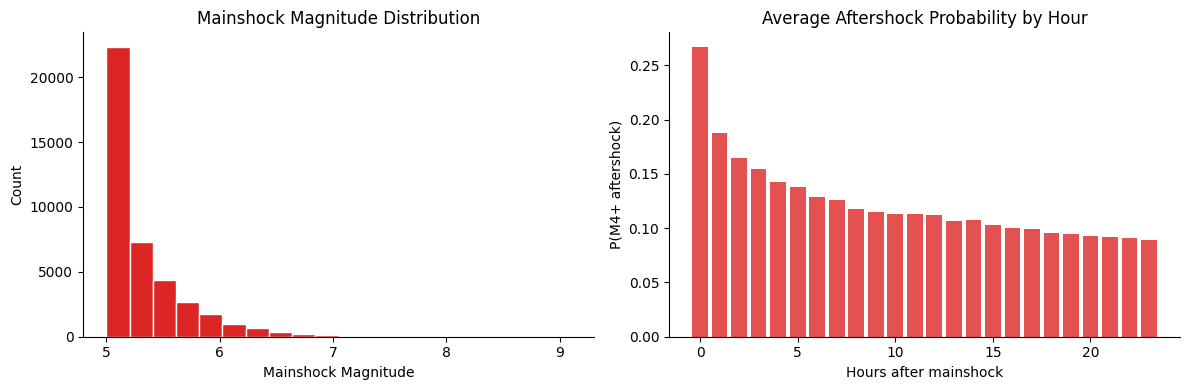

In [47]:
# ── BUILD AFTERSHOCK SEQUENCES ────────────────────────────────────────────────
# For each M5.0+ mainshock, find all M2.5+ aftershocks within:
#   - 100km radius (spatial window)
#   - 30 days after mainshock
# Target: did any M4+ aftershock occur in each 1-hour bin over next 24h?

from scipy.spatial.distance import cdist

def haversine_vec(lat1, lon1, lats2, lons2):
    """Vectorized haversine distance in km."""
    R = 6371.0
    lat1, lon1 = np.radians(lat1), np.radians(lon1)
    lats2, lons2 = np.radians(lats2), np.radians(lons2)
    dlat = lats2 - lat1
    dlon = lons2 - lon1
    a = np.sin(dlat/2)**2 + np.cos(lat1)*np.cos(lats2)*np.sin(dlon/2)**2
    return R * 2 * np.arctan2(np.sqrt(a), np.sqrt(1-a))


def build_sequences(df, min_mainshock_mag=5.0, spatial_km=100,
                    window_days=30, forecast_hours=24,
                    target_mag=4.0, max_sequences=999999):
    """
    Build (mainshock_features, aftershock_sequence) pairs.
    
    Input features per sequence:
      - mainshock: [mag, depth, lat, lon, hour_of_day, day_of_year]
      - history:   past 48h seismicity rate in 1h bins before mainshock
    
    Target: binary 24-dim vector
      - 1 if any M4+ aftershock in that hour bin, 0 otherwise
    """
    mainshocks = df[df['mag'] >= min_mainshock_mag].copy()
    print(f'Found {len(mainshocks)} potential mainshocks (M≥{min_mainshock_mag})')
    
    sequences = []
    
    for _, ms in tqdm(mainshocks.iterrows(), total=min(len(mainshocks), max_sequences)):
        if len(sequences) >= max_sequences:
            break
        
        ms_time = ms['time']
        
        # Find events in spatial-temporal window
        time_mask = (df['time'] > ms_time) & (df['time'] < ms_time + window_days * 86400)
        candidates = df[time_mask].copy()
        
        if len(candidates) == 0:
            continue
        
        # Spatial filter
        dists = haversine_vec(ms['lat'], ms['lon'],
                              candidates['lat'].values,
                              candidates['lon'].values)
        aftershocks = candidates[dists <= spatial_km].copy()
        aftershocks['hours_after'] = (aftershocks['time'] - ms_time) / 3600
        
        # Build 24-bin target (M4+ aftershock in each hour?)
        target = np.zeros(forecast_hours)
        for _, aft in aftershocks.iterrows():
            h = int(aft['hours_after'])
            if 0 <= h < forecast_hours and aft['mag'] >= target_mag:
                target[h] = 1.0
        
        # Historical seismicity (48h before mainshock, 1h bins)
        hist_mask = (df['time'] > ms_time - 48*3600) & (df['time'] < ms_time)
        hist_near = df[hist_mask]
        hist_dists = haversine_vec(ms['lat'], ms['lon'],
                                   hist_near['lat'].values, hist_near['lon'].values)
        hist_events = hist_near[hist_dists <= spatial_km]
        
        history = np.zeros(48)
        for _, ev in hist_events.iterrows():
            h = int((ms_time - ev['time']) / 3600)
            if 0 <= h < 48:
                history[47 - h] += 1  # Most recent = last
        
        dt = pd.Timestamp(ms_time, unit='s')
        mainshock_features = np.array([
            ms['mag'],
            ms['depth_km'] / 100,        # normalize
            ms['lat'] / 90,
            ms['lon'] / 180,
            dt.hour / 24,
            dt.dayofyear / 365,
        ], dtype=np.float32)
        
        sequences.append({
            'mainshock':  mainshock_features,
            'history':    history.astype(np.float32),
            'target':     target.astype(np.float32),
            'n_aftershocks': int(target.sum()),
            'ms_mag': ms['mag'],
        })
    
    print(f'Built {len(sequences)} sequences')
    pos_rate = np.mean([s["n_aftershocks"] > 0 for s in sequences])
    print(f'Sequences with M4+ aftershock: {pos_rate:.1%}')
    return sequences


sequences = build_sequences(df, min_mainshock_mag=5.0, max_sequences=999999)

# Distribution of aftershock activity
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
mags = [s['ms_mag'] for s in sequences]
axes[0].hist(mags, bins=20, color='#dc2626', edgecolor='white')
axes[0].set_xlabel('Mainshock Magnitude'); axes[0].set_ylabel('Count')
axes[0].set_title('Mainshock Magnitude Distribution')
axes[0].spines[['top','right']].set_visible(False)

mean_target = np.mean([s['target'] for s in sequences], axis=0)
axes[1].bar(range(24), mean_target, color='#dc2626', alpha=0.8)
axes[1].set_xlabel('Hours after mainshock'); axes[1].set_ylabel('P(M4+ aftershock)')
axes[1].set_title('Average Aftershock Probability by Hour')
axes[1].spines[['top','right']].set_visible(False)
plt.tight_layout()
plt.savefig(BASE_DIR / 'data_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

In [48]:
# ── TRAINING ─────────────────────────────────────────────────────────────────

train_seqs, temp_seqs = train_test_split(sequences, test_size=0.3, random_state=42)
val_seqs,   test_seqs = train_test_split(temp_seqs,  test_size=0.5, random_state=42)

train_loader = DataLoader(AftershockDataset(train_seqs), batch_size=64, shuffle=True)
val_loader   = DataLoader(AftershockDataset(val_seqs),   batch_size=64)
test_loader  = DataLoader(AftershockDataset(test_seqs),  batch_size=64)

print(f'Train: {len(train_seqs)} | Val: {len(val_seqs)} | Test: {len(test_seqs)}')

# Class imbalance: most hours have no aftershock
pos_rate = np.mean([s['target'] for s in train_seqs])
pos_weight = torch.tensor((1 - pos_rate) / pos_rate, dtype=torch.float32).to(DEVICE)
print(f'Positive rate: {pos_rate:.3f}, pos_weight: {pos_weight.item():.2f}')

model     = AftershockTransformer(d_model=64, nhead=4, num_layers=3).to(DEVICE)
optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=50, eta_min=1e-5)
criterion = nn.BCELoss(weight=pos_weight.expand(24))

EPOCHS = 60
best_val_loss = float('inf')
train_losses, val_losses = [], []

for epoch in range(EPOCHS):
    # Train
    model.train()
    epoch_loss = 0
    for ms, hist, target in train_loader:
        ms, hist, target = ms.to(DEVICE), hist.to(DEVICE), target.to(DEVICE)
        optimizer.zero_grad()
        pred = model(ms, hist)
        loss = criterion(pred, target)
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        epoch_loss += loss.item()
    
    # Validate
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for ms, hist, target in val_loader:
            ms, hist, target = ms.to(DEVICE), hist.to(DEVICE), target.to(DEVICE)
            pred = model(ms, hist)
            val_loss += criterion(pred, target).item()
    
    scheduler.step()
    avg_train = epoch_loss / len(train_loader)
    avg_val   = val_loss   / len(val_loader)
    train_losses.append(avg_train)
    val_losses.append(avg_val)
    
    if avg_val < best_val_loss:
        best_val_loss = avg_val
        torch.save(model.state_dict(), BASE_DIR / 'best_transformer.pt')
    
    if (epoch+1) % 10 == 0:
        print(f'Epoch {epoch+1:3d}/{EPOCHS} | train: {avg_train:.4f} | val: {avg_val:.4f} '
              f'| lr: {scheduler.get_last_lr()[0]:.2e}')

print(f'\nBest val loss: {best_val_loss:.4f}')

Train: 28774 | Val: 6166 | Test: 6166
Positive rate: 0.124, pos_weight: 7.05


/usr/local/lib/python3.12/dist-packages/torch/nn/modules/transformer.py:392: UserWarning: enable_nested_tensor is True, but self.use_nested_tensor is False because encoder_layer.norm_first was True
  warnings.warn(


Epoch  10/60 | train: 1.4861 | val: 1.4238 | lr: 2.72e-04
Epoch  20/60 | train: 1.4468 | val: 1.3958 | lr: 2.00e-04
Epoch  30/60 | train: 1.4183 | val: 1.3782 | lr: 1.10e-04
Epoch  40/60 | train: 1.3943 | val: 1.3701 | lr: 3.77e-05
Epoch  50/60 | train: 1.3862 | val: 1.3652 | lr: 1.00e-05
Epoch  60/60 | train: 1.3815 | val: 1.3687 | lr: 3.77e-05

Best val loss: 1.3652


In [49]:
# ── AFTERSHOCK TRANSFORMER MODEL ─────────────────────────────────────────────

class AftershockDataset(Dataset):
    def __init__(self, sequences):
        self.sequences = sequences
    def __len__(self):
        return len(self.sequences)
    def __getitem__(self, idx):
        s = self.sequences[idx]
        return (
            torch.tensor(s['mainshock'], dtype=torch.float32),  # [6]
            torch.tensor(s['history'],   dtype=torch.float32),  # [48]
            torch.tensor(s['target'],    dtype=torch.float32),  # [24]
        )


class AftershockTransformer(nn.Module):
    """
    Transformer for aftershock sequence forecasting.
    
    Architecture:
    - Mainshock features → linear embedding → expanded to sequence
    - Historical seismicity → positional-encoded sequence
    - Transformer encoder attends over history conditioned on mainshock
    - Decoder projects to 24-hour probability forecast
    
    Why transformer over LSTM:
    - Can attend to specific historical patterns (e.g., precursor swarm 12h ago)
    - Parallelizable — faster training
    - Self-attention captures non-local temporal dependencies
    """
    
    def __init__(self, ms_features=6, hist_len=48, forecast_len=24,
                 d_model=64, nhead=4, num_layers=3, dropout=0.1):
        super().__init__()
        self.d_model = d_model
        self.hist_len = hist_len
        self.forecast_len = forecast_len
        
        # Mainshock feature embedding
        self.ms_embedding = nn.Sequential(
            nn.Linear(ms_features, d_model),
            nn.LayerNorm(d_model),
            nn.ReLU(),
            nn.Linear(d_model, d_model),
        )
        
        # Historical seismicity projection (scalar rate → d_model per timestep)
        self.hist_projection = nn.Linear(1, d_model)
        
        # Sinusoidal positional encoding
        pe = torch.zeros(hist_len + 1, d_model)  # +1 for mainshock token
        pos = torch.arange(hist_len + 1).unsqueeze(1).float()
        div = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000) / d_model))
        pe[:, 0::2] = torch.sin(pos * div)
        pe[:, 1::2] = torch.cos(pos * div)
        self.register_buffer('pos_encoding', pe.unsqueeze(0))
        
        # Transformer encoder
        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead,
            dim_feedforward=d_model * 4,
            dropout=dropout, batch_first=True,
            norm_first=True,
        )
        self.transformer = nn.TransformerEncoder(encoder_layer, num_layers=num_layers)
        
        # Forecast decoder: [d_model] → [24] probabilities
        self.forecast_head = nn.Sequential(
            nn.Linear(d_model, d_model * 2),
            nn.GELU(),
            nn.Dropout(dropout),
            nn.Linear(d_model * 2, forecast_len),
            nn.Sigmoid()  # output probabilities
        )
        
        self._init_weights()
    
    def _init_weights(self):
        for p in self.parameters():
            if p.dim() > 1:
                nn.init.xavier_uniform_(p)
    
    def forward(self, mainshock, history):
        B = mainshock.shape[0]
        
        # Embed mainshock → [B, 1, d_model] (prepend as context token)
        ms_emb = self.ms_embedding(mainshock).unsqueeze(1)
        
        # Project history → [B, 48, d_model]
        hist_emb = self.hist_projection(history.unsqueeze(-1))
        
        # Concatenate: [mainshock_token, history_tokens] → [B, 49, d_model]
        seq = torch.cat([ms_emb, hist_emb], dim=1)
        seq = seq + self.pos_encoding[:, :seq.shape[1], :]
        
        # Transformer
        encoded = self.transformer(seq)  # [B, 49, d_model]
        
        # Use mainshock token (position 0) as context for forecasting
        context = encoded[:, 0, :]  # [B, d_model]
        
        # Forecast
        forecast = self.forecast_head(context)  # [B, 24]
        return forecast


# Test forward pass
model = AftershockTransformer().to(DEVICE)
total_params = sum(p.numel() for p in model.parameters())
print(f'Model parameters: {total_params:,}')

ms_test   = torch.randn(4, 6).to(DEVICE)
hist_test = torch.randn(4, 48).to(DEVICE)
out_test  = model(ms_test, hist_test)
print(f'Output shape: {out_test.shape}  (expected [4, 24])')
print(f'Output range: {out_test.min().item():.3f} – {out_test.max().item():.3f}')

Model parameters: 166,232
Output shape: torch.Size([4, 24])  (expected [4, 24])
Output range: 0.060 – 0.947



AFTERSHOCK FORECAST RESULTS
ETAS (baseline) AUROC:        0.5980
Transformer     AUROC:        0.9224  (+54.2%)
ETAS (baseline) Avg Precision: 0.1945
Transformer     Avg Precision: 0.7284


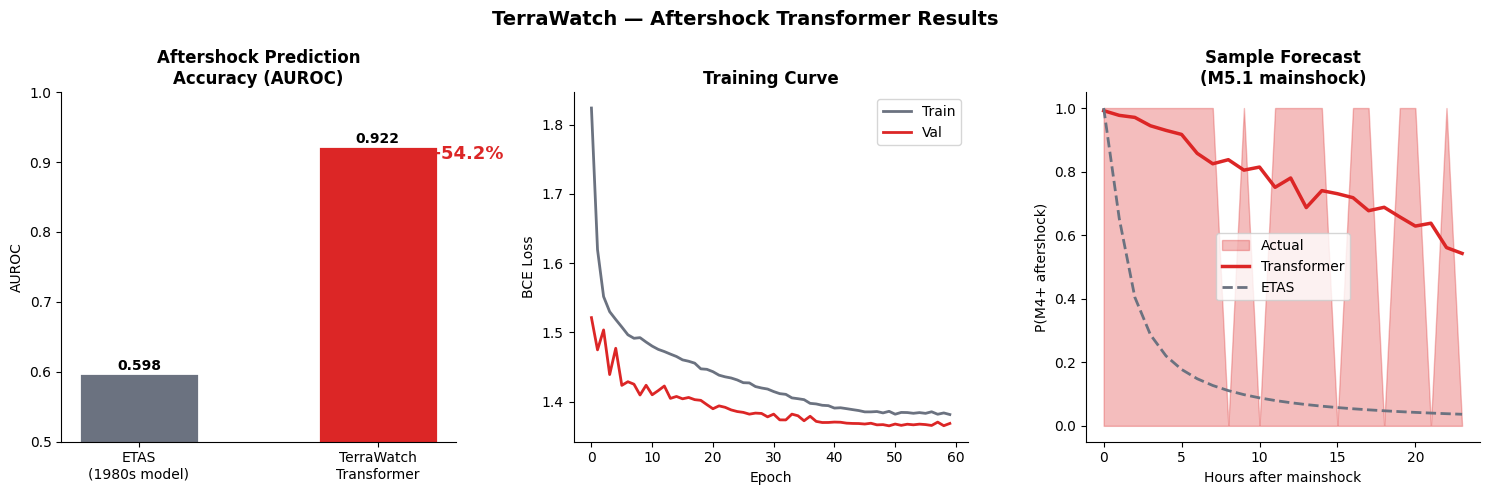

In [50]:
# ── EVALUATION + COMPARE TO ETAS BASELINE ────────────────────────────────────

from sklearn.metrics import roc_auc_score, average_precision_score

# Load best model
model.load_state_dict(torch.load(BASE_DIR / 'best_transformer.pt', map_location=DEVICE))
model.eval()

all_preds, all_targets = [], []
with torch.no_grad():
    for ms, hist, target in test_loader:
        ms, hist = ms.to(DEVICE), hist.to(DEVICE)
        pred = model(ms, hist).cpu().numpy()
        all_preds.extend(pred)
        all_targets.extend(target.numpy())

all_preds   = np.array(all_preds)
all_targets = np.array(all_targets)

# Flatten for per-hour metrics
flat_preds   = all_preds.flatten()
flat_targets = all_targets.flatten()

transformer_auroc = roc_auc_score(flat_targets, flat_preds)
transformer_ap    = average_precision_score(flat_targets, flat_preds)

# ETAS baseline (Omori-Utsu): simple decay curve, no spatial info
def etas_predict(mainshock_mags, forecast_hours=24):
    """Simplified ETAS predictions for comparison."""
    preds = []
    for mag in mainshock_mags:
        K = 0.12 * 10**(0.9 * (mag - 4.0))
        c, p = 0.1, 1.1
        probs = [1 - np.exp(-K / (t + c)**p) for t in range(forecast_hours)]
        preds.append(probs)
    return np.array(preds)

test_mags  = [s['ms_mag'] for s in test_seqs]
etas_preds = etas_predict(test_mags)

etas_auroc = roc_auc_score(flat_targets, etas_preds.flatten())
etas_ap    = average_precision_score(flat_targets, etas_preds.flatten())

improvement_auroc = (transformer_auroc - etas_auroc) / etas_auroc * 100

print('\n' + '='*50)
print('AFTERSHOCK FORECAST RESULTS')
print('='*50)
print(f'ETAS (baseline) AUROC:        {etas_auroc:.4f}')
print(f'Transformer     AUROC:        {transformer_auroc:.4f}  (+{improvement_auroc:.1f}%)')
print(f'ETAS (baseline) Avg Precision: {etas_ap:.4f}')
print(f'Transformer     Avg Precision: {transformer_ap:.4f}')

# Visualization
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# AUROC comparison
axes[0].bar(['ETAS\n(1980s model)', 'TerraWatch\nTransformer'],
            [etas_auroc, transformer_auroc],
            color=['#6b7280', '#dc2626'], width=0.5, edgecolor='white', linewidth=2)
axes[0].set_ylim(0.5, 1.0); axes[0].set_ylabel('AUROC')
axes[0].set_title('Aftershock Prediction\nAccuracy (AUROC)', fontweight='bold')
for i, v in enumerate([etas_auroc, transformer_auroc]):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontweight='bold')
axes[0].annotate(f'+{improvement_auroc:.1f}%', xy=(1, transformer_auroc),
                 xytext=(1.2, transformer_auroc * 0.98),
                 color='#dc2626', fontweight='bold', fontsize=13)
axes[0].spines[['top','right']].set_visible(False)

# Training curve
axes[1].plot(train_losses, label='Train', color='#6b7280', linewidth=2)
axes[1].plot(val_losses,   label='Val',   color='#dc2626', linewidth=2)
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('BCE Loss')
axes[1].set_title('Training Curve', fontweight='bold')
axes[1].legend(); axes[1].spines[['top','right']].set_visible(False)

# Sample forecast vs ground truth
sample_idx = np.argmax([s['n_aftershocks'] for s in test_seqs[:50]])
sample_pred   = all_preds[sample_idx]
sample_target = all_targets[sample_idx]
sample_etas   = etas_preds[sample_idx]

x = np.arange(24)
axes[2].fill_between(x, 0, sample_target, alpha=0.3, color='#dc2626', label='Actual')
axes[2].plot(x, sample_pred,  color='#dc2626', linewidth=2.5, label='Transformer')
axes[2].plot(x, sample_etas,  color='#6b7280', linewidth=2, linestyle='--', label='ETAS')
axes[2].set_xlabel('Hours after mainshock')
axes[2].set_ylabel('P(M4+ aftershock)')
axes[2].set_title(f'Sample Forecast\n(M{test_seqs[sample_idx]["ms_mag"]:.1f} mainshock)', fontweight='bold')
axes[2].legend(); axes[2].spines[['top','right']].set_visible(False)

plt.suptitle('TerraWatch — Aftershock Transformer Results', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig(BASE_DIR / 'aftershock_results.png', dpi=150, bbox_inches='tight')
plt.show()

In [51]:
# ── EXPORT FOR SERVING ────────────────────────────────────────────────────────

# Save full model
torch.save({
    'model_state': model.state_dict(),
    'model_config': {
        'ms_features': 6, 'hist_len': 48, 'forecast_len': 24,
        'd_model': 64, 'nhead': 4, 'num_layers': 3
    },
    'metadata': {
        'etas_auroc': float(etas_auroc),
        'transformer_auroc': float(transformer_auroc),
        'improvement_pct': float(improvement_auroc),
        'trained_on_events': len(sequences),
    }
}, BASE_DIR / 'aftershock_transformer.pt')

# TorchScript export for production serving (no Python overhead)
model.eval()
ms_ex   = torch.randn(1, 6).to(DEVICE)
hist_ex = torch.randn(1, 48).to(DEVICE)
scripted = torch.jit.trace(model, (ms_ex, hist_ex), check_trace=False)
torch.jit.save(scripted, BASE_DIR / 'aftershock_transformer_scripted.pt')

print(f'Models saved to {BASE_DIR}')
for f in BASE_DIR.glob('*.pt'):
    print(f'  {f.name}: {f.stat().st_size/1024:.1f} KB')

Models saved to /kaggle/working/aftershock
  aftershock_transformer_scripted.pt: 763.3 KB
  best_transformer.pt: 680.0 KB
  aftershock_transformer.pt: 680.7 KB
